# ====================
# Explainable AI (XAI)
# ====================

# importing libraries and dataset

In [1]:
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.7/561.7 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [shap]


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import shap

from xgboost import XGBRegressor

In [4]:
df = pd.read_csv('../outputs/predictions/staten_island_otp_features.csv')

df.head()

,Month,Day Time,Delayed Trains,On-Time Trips,On-Time Performance,Delayed Trains (With Boat),On-Time Trips (With Boat),On-Time Performance (With Boat),Scheduled Trips,Incomplete Trips,...,OTP_Lag_1,OTP_Lag_2,OTP_Lag_3,Delayed_Trains_Lag_1,Scheduled_Trips_Lag_1,OTP_Rolling_3,OTP_Rolling_6,Delayed_Trains_Rolling_3,Delay_Rate,Next_Month_OTP
0,2006-07-01,7-Day,104,3362,0.970,192,3274,0.945,3466,26.0,...,0.983,0.968,0.965,61.0,3490.0,0.972000,0.974833,97.666667,0.030006,0.971
1,2006-08-01,7-Day,105,3506,0.971,160,3451,0.956,3611,0.0,...,0.970,0.983,0.968,104.0,3466.0,0.973667,0.978333,92.666667,0.029078,0.953
2,2006-09-01,7-Day,159,3228,0.953,220,3167,0.935,3387,0.0,...,0.971,0.970,0.983,105.0,3611.0,0.974667,0.976167,90.000000,0.046944,0.955
3,2006-10-01,7-Day,159,3401,0.955,220,3340,0.938,3560,38.0,...,0.953,0.971,0.970,159.0,3387.0,0.964667,0.968333,122.666667,0.044663,0.930
4,2006-11-01,7-Day,239,3197,0.930,303,3133,0.912,3436,20.0,...,0.955,0.953,0.971,159.0,3560.0,0.959667,0.966667,141.000000,0.069558,0.980


# Encoding

In [5]:
df = pd.get_dummies(
    df,
    columns=['Day Time', 'Season'],
    drop_first=True
)

# Defining Features

In [6]:
features = [
    'Delayed Trains',
    'On-Time Trips',
    'Scheduled Trips',
    'OTP_Lag_1',
    'OTP_Lag_2',
    'OTP_Lag_3',
    'OTP_Rolling_3',
    'OTP_Rolling_6',
    'Delayed_Trains_Lag_1',
    'Delayed_Trains_Rolling_3',
    'Delay_Rate',
    'Year',
    'Month_Number',
    'Quarter'
]

In [7]:
encoded_cols = [
    col for col in df.columns
    if 'Day Time_' in col or 'Season_' in col
]

features.extend(encoded_cols)

In [8]:
X = df[features]

y = df['Next_Month_OTP']

# time series split

In [9]:
split_index = int(len(df) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

# Train XGboost

In [10]:
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

# SHAP Explainer

In [11]:
explainer = shap.Explainer(model)

shap_values = explainer(X_test)

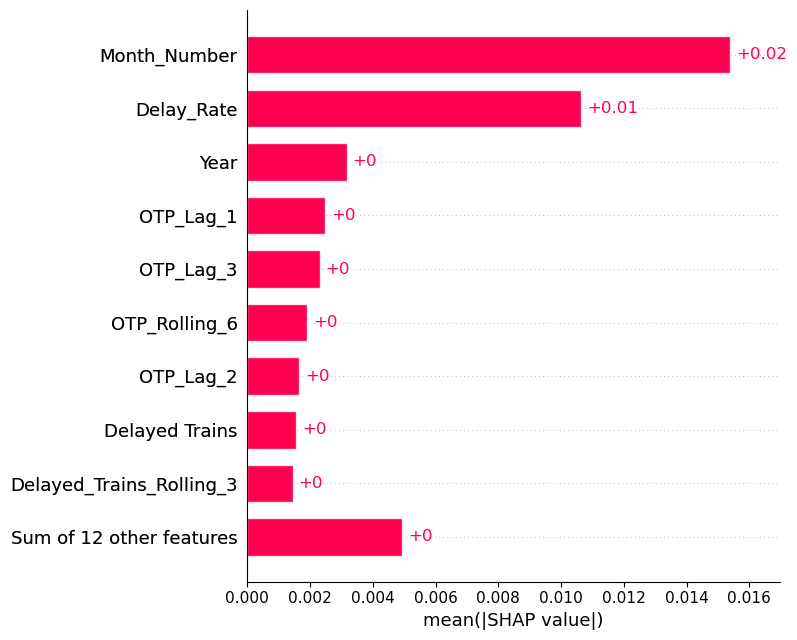

In [17]:
shap.plots.bar(shap_values, show=False)

plt.tight_layout()
plt.savefig("../outputs/figures/shap_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# SHAP Summary plot

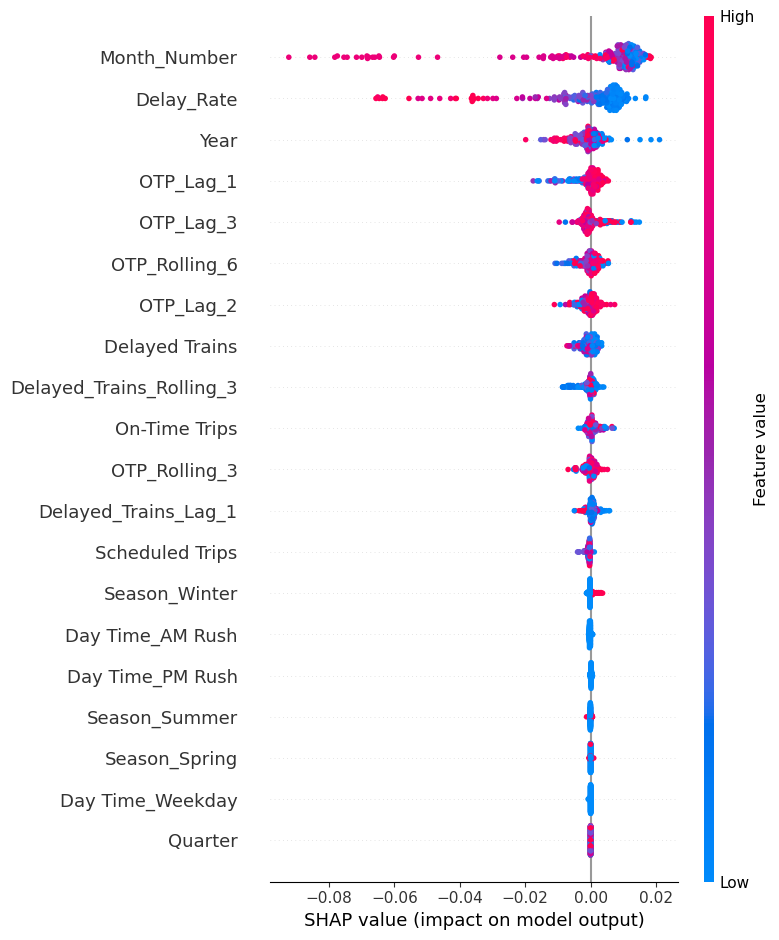

In [18]:
shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.tight_layout()
plt.savefig("../outputs/figures/shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()

# Explaining individual prediction 

In [14]:
sample_index = 10

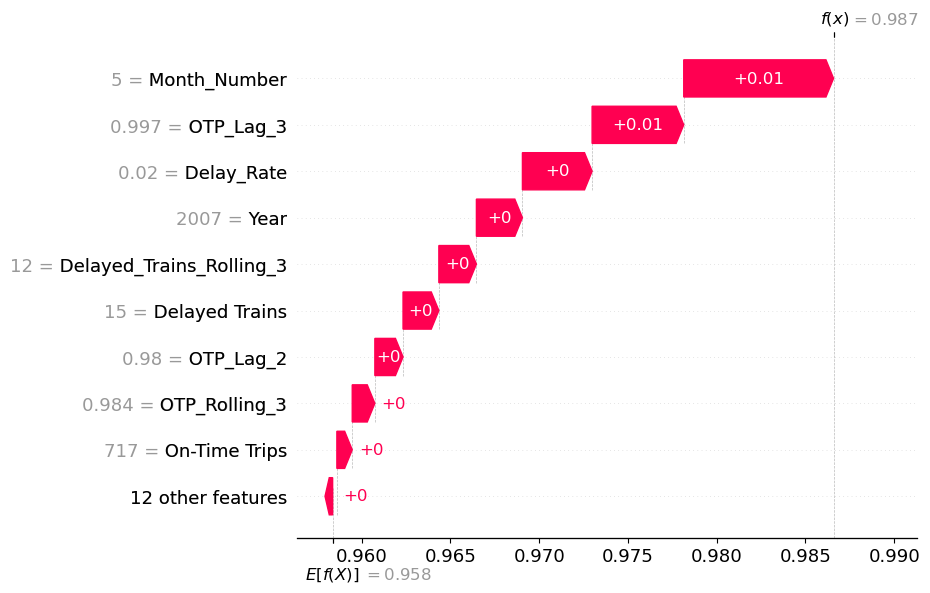

In [15]:
shap.plots.waterfall(
    shap_values[sample_index]
)

In [16]:
plt.savefig('../outputs/figures/shap_summary.png')

<Figure size 640x480 with 0 Axes>